In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
data=pd.read_csv('netflix-699bb0d94f78e745148155.csv')
data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."


In [23]:

data['country'].value_counts().head(10)


country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

In [24]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [51]:
data.describe()

,date_added,release_year,Annee
count,8709,8807.000000,8709.000000
mean,2019-05-23 01:45:29.452290,2014.180198,2018.887932
min,2008-01-01 00:00:00,1925.000000,2008.000000
25%,2018-04-20 00:00:00,2013.000000,2018.000000
50%,2019-07-12 00:00:00,2017.000000,2019.000000
75%,2020-08-26 00:00:00,2019.000000,2020.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000
std,NaN,8.819312,1.567961


In [50]:
data.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           3
duration         0
listed_in        0
description      0
Annee           98
dtype: int64

In [46]:
values = ['74 min','84 min','66 min']
mask = data['rating'].isin(values)
data.loc[mask,'duration'] = data.loc[mask,'rating']
data.loc[mask,'rating']= np.nan

In [45]:
data["rating"].unique()

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR', 'TV-Y7-FV',       'UR']
Length: 17, dtype: str

In [44]:
x = data['rating'].mode()[0]
data['rating'] = data['rating'].fillna(x, inplace= True)

C:\Users\lonovo\AppData\Local\Temp\ipykernel_7368\1038901875.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  data['rating'] = data['rating'].fillna(x, inplace= True)


In [42]:
data.groupby(['type']).count()

,show_id,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Annee
type,,,,,,,,,,,,
Movie,6131,6131,5943,5656,5691,6131,6131,6129,6128,6131,6131,6131
TV Show,2676,2676,230,2326,2285,2578,2676,2674,2676,2676,2676,2578


In [98]:
data.fillna('nkkkk', inplace= True)

TypeError: Invalid value 'nkkkk' for dtype 'datetime64[us]'

In [25]:
data['date_added'] = pd.to_datetime(data['date_added'], errors='coerce')

In [65]:
data['Annee']=data['date_added'].dt.year
data['Annee']
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Annee,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,null,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,2021.0
1,s2,TV Show,Blood & Water,null,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",null,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,2021.0
3,s4,TV Show,Jailbirds New Orleans,null,null,null,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,2021.0
4,s5,TV Show,Kota Factory,null,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,2021.0


In [64]:
data

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,Annee,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,null,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,2021.0
1,s2,TV Show,Blood & Water,null,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",null,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,2021.0
3,s4,TV Show,Jailbirds New Orleans,null,null,null,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,2021.0
4,s5,TV Show,Kota Factory,null,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,2021.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,2019.0
8803,s8804,TV Show,Zombie Dumb,null,null,null,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019.0,2019.0
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,2019.0
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,2020.0


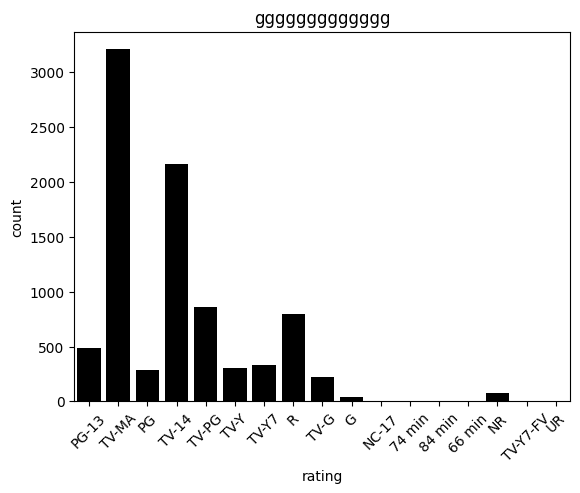

In [27]:
sns.countplot(x="rating", data = data,color='black')
plt.xticks(rotation =45)
plt.title("ggggggggggggg")
plt.show()


<Axes: xlabel='rating'>

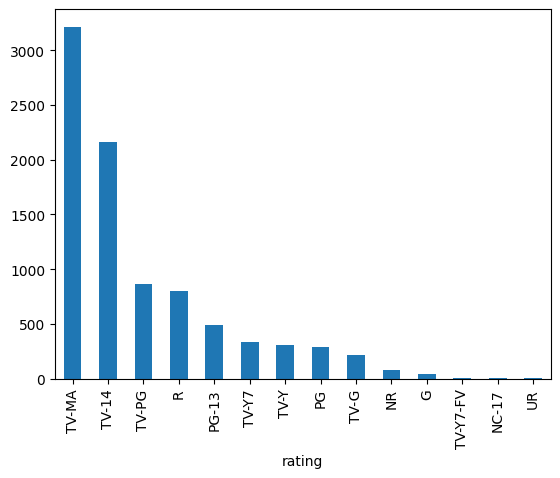

In [ ]:
data['rating'].value_counts().plot(kind='bar')



Text(0.5, 1.0, ' films vs séries')

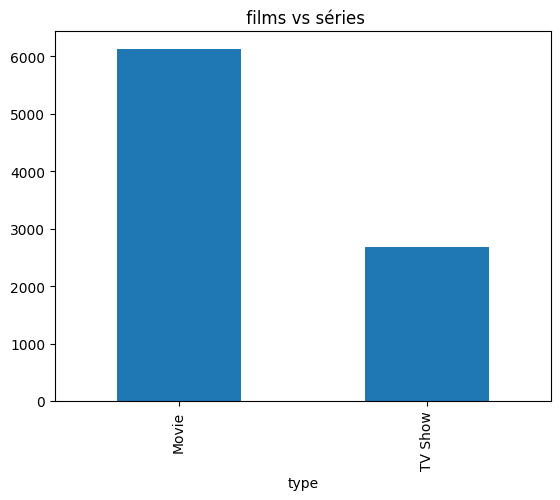

In [ ]:
data["type"].value_counts().plot(kind='bar') 
plt.title(" films vs séries")

Text(0.5, 1.0, ' films vs séries')

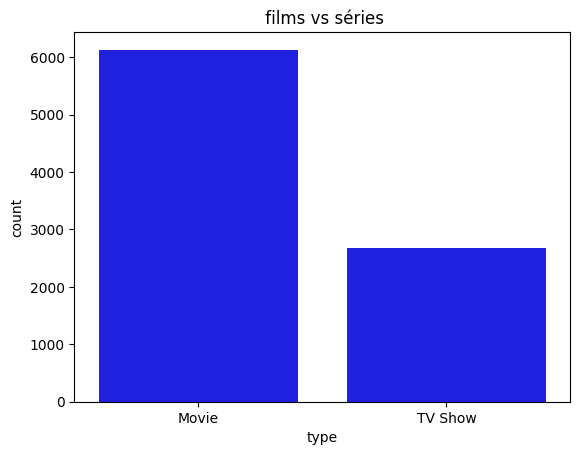

In [ ]:
sns.countplot(x="type", data = data,color='blue')
plt.title(" films vs séries")

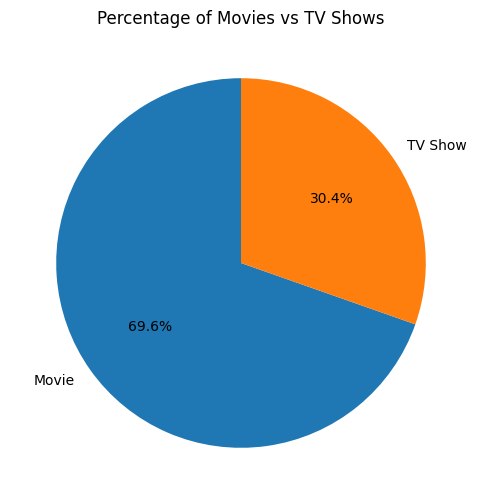

In [ ]:
percentage = data["type"].value_counts(normalize=True) * 100

plt.figure(figsize=(6,6))
plt.pie(
    percentage.values,
    labels=percentage.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Percentage of Movies vs TV Shows")
plt.show()

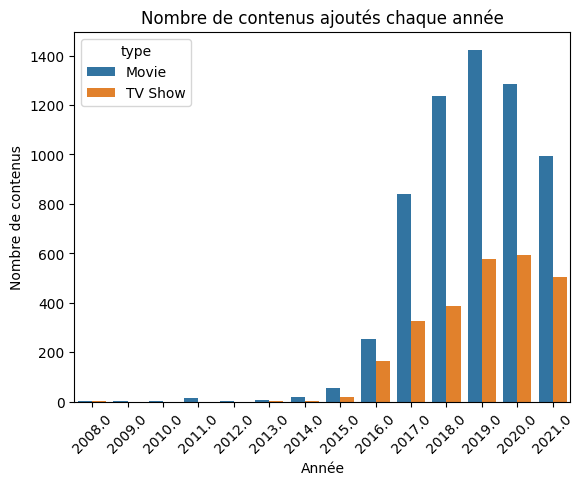

In [162]:

sns.countplot(
    data=data,
    x='Annee',
    hue='type'
)

plt.title("Nombre de contenus ajoutés chaque année")
plt.xlabel("Année")
plt.xticks(rotation =45)
plt.ylabel("Nombre de contenus")
plt.show()

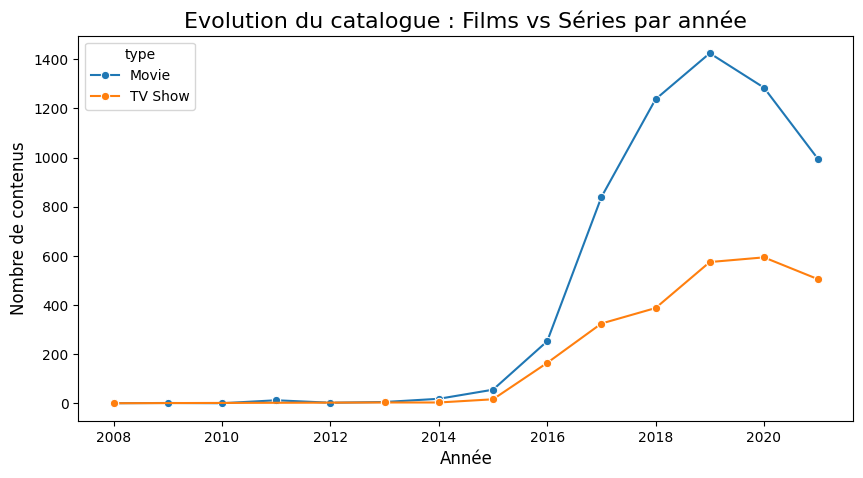

In [55]:

data['date_added'] = pd.to_datetime(data['date_added'])


data['year_added'] = data['date_added'].dt.year


year_type = data.groupby(['year_added', 'type']).size().reset_index(name='count')


plt.figure(figsize=(10,5))

sns.lineplot(
    data=year_type,
    x='year_added',
    y='count',
    hue='type',
    marker='o'
)

plt.title("Evolution du catalogue : Films vs Séries par année", fontsize=16)
plt.xlabel("Année", fontsize=12)
plt.ylabel("Nombre de contenus", fontsize=12)

plt.show()

In [ ]:
data["release_year"].unique()

array([2020, 2021, 1993, 2018, 1996, 1998, 1997, 2010, 2013, 2017, 1975,
       1978, 1983, 1987, 2012, 2001, 2014, 2002, 2003, 2004, 2011, 2008,
       2009, 2007, 2005, 2006, 1994, 2015, 2019, 2016, 1982, 1989, 1990,
       1991, 1999, 1986, 1992, 1984, 1980, 1961, 2000, 1995, 1985, 1976,
       1959, 1988, 1981, 1972, 1964, 1945, 1954, 1979, 1958, 1956, 1963,
       1970, 1973, 1925, 1974, 1960, 1966, 1971, 1962, 1969, 1977, 1967,
       1968, 1965, 1946, 1942, 1955, 1944, 1947, 1943])

In [94]:
# 1. Filter the data for only TV Shows between 2011 and 2021
series_11_to_21 = data[(data['type'] == 'TV Show') & 
                     (data['release_year'] >= 2011) & 
                     (data['release_year'] <= 2021)]

# 2. Get the total value and print it
total_series = len(series_11_to_21)
print(f"The total number of TV Shows (series) from 2011 to 2021 is: {total_series} TV Show")

# 3. Create a chart to show the trend
plt.figure(figsize=(10, 5))
sns.countplot(
    data=series_11_to_21, 
    x='release_year', 
    color='orange' 
)

plt.title("Number of TV Shows Released from 2011 to 2021", fontsize=14)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

TypeError: Invalid comparison between dtype=datetime64[ns] and int